## Setup & Imports

In [3]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = "../data"
EXT_DIR  = "../data/external"
FIG_DIR  = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

## Load Clinical Markers

| Column | Type | Description | Notes |
|--------|------|-------------|-------|
| `Record` | int | Record number |  |
| `Age` | int | **Birth year**, not age | |
| `sex` | string | Sex | "Female", "Male" |
| `disease.type` | string | Disease stage/type | "Early Disease Stage", "Fast Disease Progression", "Late Disease Stage" |
| `Id` | int | Participant ID | **Links to sensor filename.** e.g., Id=3389 → `RHourly_3389.csv` |

In [7]:
clinical = pd.read_csv(f"{DATA_DIR}/ClinicalMarkers_final.csv")

# Derive actual age from birth year
clinical["age"] = 2026 - clinical["age"]

clinical.head()

,record,age,sex,disease_type,id
0,1,55,Female,Late Disease Stage,3389
1,2,29,Female,Early Disease Stage,4349
2,3,45,Female,Late Disease Stage,6155
3,4,53,Female,Early Disease Stage,9173
4,5,45,Female,Early Disease Stage,2815


In [9]:
clinical["sex"].value_counts()

sex
Female    29
Male      15
Name: count, dtype: int64

In [8]:
clinical["disease_type"].value_counts()

disease_type
Late Disease Stage          19
Early Disease Stage         18
Fast Disease Progression     7
Name: count, dtype: int64

<Axes: >

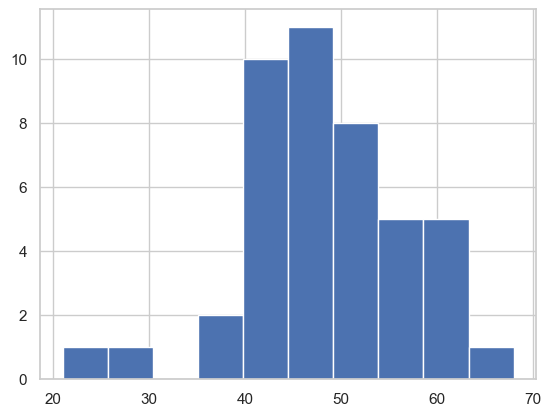

In [11]:
clinical["age"].hist(bins=10)

## Load Hourly Sensor Data

| Column | Type | Description | Notes |
|--------|------|-------------|-------|
| `time` | string | Datetime of measurement | Format: `YYYY-MM-DD HH:MM:SS` |
| `steps` | int | Steps in that hour | Range: [0, 6124] |
| `sleep` | int (byte) | Minutes of sleep in that hour | Range: [0, 60] |
| `heartrate` | float | Hourly average BPM | There are missing values |

In [35]:
files = glob.glob(f"{DATA_DIR}/Hourly Sensor Data/RHourly_*.csv")
print(f"Found {len(files)} files")

chunks = []
for fp in files:
    pid = int(os.path.basename(fp).replace("RHourly_", "").replace(".csv", ""))
    df = pd.read_csv(fp)
    df["id"] = pid
    chunks.append(df)

sensor = pd.concat(chunks, ignore_index=True)
print(f"Total rows: {len(sensor):,}")

Found 44 files
Total rows: 57,928


In [37]:
sensor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57928 entries, 0 to 57927
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       57928 non-null  object 
 1   steps      57928 non-null  float64
 2   sleep      57928 non-null  int64  
 3   heartrate  54409 non-null  float64
 4   id         57928 non-null  int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 2.2+ MB


In [43]:
sensor.describe()

,steps,sleep,heartrate,id
count,57928.000000,57928.000000,54409.000000,57928.000000
mean,303.528904,17.878677,78.903074,5721.351436
std,560.602875,26.482681,13.426584,2466.696196
min,0.000000,0.000000,45.463492,1120.000000
25%,0.000000,0.000000,68.894811,3389.000000
50%,83.891495,0.000000,77.742151,6155.000000
75%,368.449550,60.000000,87.557717,7928.000000
max,6124.954100,60.000000,139.439355,9926.000000


In [38]:
sensor[~sensor['heartrate'].isna()].head()

,time,steps,sleep,heartrate,id
9,2021-08-19 09:00:00,18.418821,0,73.009100,8446
10,2021-08-19 10:00:00,924.140200,0,83.878363,8446
11,2021-08-19 11:00:00,924.322510,0,91.559950,8446
12,2021-08-19 12:00:00,803.601870,0,94.781008,8446
13,2021-08-19 13:00:00,359.983090,0,85.510183,8446


In [52]:
sensor[~sensor['heartrate'].isna()].groupby("id")["time"].agg(
    min_time="min",
    max_time="max",
    hr_count="count"
)

,min_time,max_time,hr_count
id,,,
1120,2021-06-08 13:00:00,2021-08-03 23:00:00,1343
1556,2021-03-10 08:00:00,2021-05-05 23:00:00,1357
1971,2021-09-02 08:00:00,2021-11-06 23:00:00,1523
2130,2021-06-01 09:00:00,2021-08-02 23:00:00,1443
2589,2021-03-24 08:00:00,2021-05-20 23:00:00,1380
2676,2021-08-10 08:00:00,2021-10-05 23:00:00,1355
2815,2021-02-05 11:00:00,2021-04-02 23:00:00,1343
2854,2021-03-23 15:00:00,2021-06-27 23:00:00,2233
2909,2021-05-04 13:00:00,2021-06-14 07:00:00,967


In [41]:
fig = px.line(
    sensor.sort_values("time"),
    x="time",
    y="heartrate",
    color="id",          # one line per participant
    line_group="id",
    labels={"heartrate": "Heart Rate (BPM)", "time": "Time", "id": "Participant ID"},
    title="Heart Rate Over Time by Participant",
)
fig.update_traces(opacity=0.6)
fig.show()


In [47]:
sensor["heartrate"] = pd.to_numeric(sensor["heartrate"], errors="coerce")

# Parse datetime
sensor["time"] = pd.to_datetime(sensor["time"])
sensor["date"] = sensor["time"].dt.date
sensor["hour"] = sensor["time"].dt.hour
sensor["week"] = sensor["time"].dt.isocalendar().week.astype(int)

sensor.dtypes

time         datetime64[ns]
steps               float64
sleep                 int64
heartrate           float64
id                    int64
date                 object
hour                  int32
week                  int64
dtype: object

In [50]:
sensor[~sensor['heartrate'].isna()].head()

,time,steps,sleep,heartrate,id,date,hour,week
9,2021-08-19 09:00:00,18.418821,0,73.009100,8446,2021-08-19,9,33
10,2021-08-19 10:00:00,924.140200,0,83.878363,8446,2021-08-19,10,33
11,2021-08-19 11:00:00,924.322510,0,91.559950,8446,2021-08-19,11,33
12,2021-08-19 12:00:00,803.601870,0,94.781008,8446,2021-08-19,12,33
13,2021-08-19 13:00:00,359.983090,0,85.510183,8446,2021-08-19,13,33


## Merge Sensor + Clinical

In [53]:
df = pd.merge(clinical[["id", "age", "sex", "disease_type"]], sensor, on="id", how="left")
print(df.shape)
df.head()

(57928, 11)


,id,age,sex,disease_type,time,steps,sleep,heartrate,date,hour,week
0,3389,55,Female,Late Disease Stage,2021-01-08 00:00:00,0.0,0,NaN,2021-01-08,0,1
1,3389,55,Female,Late Disease Stage,2021-01-08 01:00:00,0.0,0,NaN,2021-01-08,1,1
2,3389,55,Female,Late Disease Stage,2021-01-08 02:00:00,0.0,0,NaN,2021-01-08,2,1
3,3389,55,Female,Late Disease Stage,2021-01-08 03:00:00,0.0,0,NaN,2021-01-08,3,1
4,3389,55,Female,Late Disease Stage,2021-01-08 04:00:00,0.0,0,NaN,2021-01-08,4,1
